In [54]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from shapely.geometry import box

In [55]:
import os
print(os.getcwd())

C:\Users\kalmanj\Documents\SCHOOL\Practicum\south-africa-healthcare


In [56]:
sal = gpd.read_file("../2011_census/2011_Census/ea_sal_kzn_gp.shp")

wards = gpd.read_file("../2023_Census/SA_Wards2020.shp")

wards_with_pop = gpd.read_file("../2023_Census/census_ward_2023_with_pop.csv")

In [112]:
import pandas as pd
pd.set_option('display.float_format', '{:,.0f}'.format)
import pandas as pd

pd.set_option('display.max_columns', 100)

In [58]:
wards = wards.merge(
    wards_with_pop[['WardID', 'Total',]],
    on='WardID',
    how='left'
)

In [59]:
wards = wards[wards['Province'].isin(['Gauteng', 'KwaZulu-Natal'])].copy()


In [60]:
sal['population'].isna().sum()

np.int64(2084)

In [61]:
sal_with_ward = gpd.read_file("../sal_w_ward_new.shp")

In [114]:

pd.set_option('display.float_format', '{:,.2f}'.format)

In [62]:
sal_with_ward=sal_with_ward.rename(columns={'census_war': 'WardID'})

In [63]:
sal_with_ward = sal_with_ward.merge(
    wards[['WardID', 'Total']],
    on='WardID',
    how='left'
)
    

In [64]:
sal_wards= sal_with_ward[['WardID', 'EA_CODE', 'sal2011_po', "Total", 'EA_GTYPE', 'EA_TYPE', 'F4_class', 'num_houses', 'AREA',
                         'Black_Afri', 'White', 'Coloured', 'Indian_or', 'Other',    ]]

In [65]:
sal_wards=sal_wards.rename(columns={'sal2011_po': 'sal2011_pop',
                            'Total':'ward2023_pop',
                                'F4_class': 'econ_status',
                                'num_houses': 'houses2011'})

In [66]:
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(r'_\*$', '', regex=True)
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(
    'Smallholdings', 'Small holdings'
)

In [67]:
sal_wards.loc[sal_wards['sal2011_pop'] == 0, 'sal2011_pop'] = sal_wards['houses2011']*3
sal_wards['new_areakm']=sal_wards['AREA']/1000000

sal_wards['sal_dense'] = (
    sal_wards['sal2011_pop'].astype(float) /
    sal_wards['new_areakm'].astype(float)
)

In [68]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,AREA,Black_Afri,White,Coloured,Indian_or,Other,new_areakm,sal_dense
0,52103007,"50,310,272.000",559.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,131.000,"6,059,185.934",558,0,0,1,0,6.059,92.257
1,52103007,"50,310,271.000",713.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,167.000,"3,506,975.950",713,0,0,0,0,3.507,203.309
2,52103007,"50,310,262.000",443.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,135.000,"1,911,598.773",443,0,0,0,0,1.912,231.743
3,52103007,"50,310,266.000",743.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,154.000,"1,687,526.670",740,0,1,1,1,1.688,440.289
4,52103006,"50,310,265.000",339.000,7902.254373200000373,Traditional,Traditional residential,Non_Wealthy,92.000,"2,657,911.097",339,0,0,0,0,2.658,127.544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,59500015,"59,912,265.000",0.000,44864.912303999997675,Urban,Vacant,None,0.000,"515,945.162",None,None,None,None,None,0.516,0.000
39173,59500103,"59,914,036.000",540.000,39704.126380000001518,Urban,Small holdings,Wealthy,180.000,"4,055,769.204",None,None,None,None,None,4.056,133.144
39174,59500049,"59,915,062.000",0.000,52055.310791000003519,Urban,Formal residential,None,0.000,"21,079.349",None,None,None,None,None,0.021,0.000
39175,59500063,"59,911,731.000",78.000,41787.592755999998190,Urban,Informal residential,Non_Wealthy,26.000,"538,521.795",None,None,None,None,None,0.539,144.841


In [69]:
sal_wards['ward2023_pop'] = pd.to_numeric(sal_wards['ward2023_pop'], errors='coerce')
sal_wards['sal2011_pop']= pd.to_numeric(sal_wards['sal2011_pop'], errors='coerce')

In [70]:
sal_wards[sal_wards.duplicated(subset='EA_CODE', keep=False)]
sal_wards = sal_wards.drop_duplicates(subset='EA_CODE', keep='first')

In [71]:
#Calculating proportion of SAL pop within Ward pop

ward2011_sum = sal_wards.groupby('WardID', as_index=False)['sal2011_pop'].sum()
ward2011_sum = ward2011_sum.rename(columns={'sal2011_pop': 'ward2011_sum'})
sal_wards = sal_wards.merge(
    ward2011_sum,
    on='WardID',
    how='left'
)


sal_wards['share2011']=sal_wards['sal2011_pop']/sal_wards['ward2011_sum']

In [72]:
sal_wards['share2011'].describe()

count   38,380.000
mean         0.037
std          0.035
min          0.000
25%          0.015
50%          0.025
75%          0.050
max          0.600
Name: share2011, dtype: float64

In [73]:
#SAL weights based on density and area

In [74]:

gtype_growth = sal_wards.groupby('EA_TYPE').agg(
    pop2011=('ward2011_sum','sum'),
    pop2023=('ward2023_pop','sum')
).reset_index()


gtype_growth['growth_ratio'] = gtype_growth['pop2023'] / gtype_growth['pop2011']

weights_dict = dict(zip(gtype_growth['EA_TYPE'], gtype_growth['growth_ratio']))
sal_wards['gweight'] = sal_wards['EA_TYPE'].map(weights_dict)

In [75]:
sal_wards['gweight'].describe()

count   38,380.000
mean         1.094
std          0.196
min          0.762
25%          0.879
50%          1.159
75%          1.320
max          1.333
Name: gweight, dtype: float64

In [76]:
sal_wards['dasym_weight']= sal_wards['share2011']*sal_wards['gweight']
sal_wards['dasym_weight'] = sal_wards['dasym_weight']/sal_wards.groupby('WardID')['dasym_weight'].transform('sum')

In [77]:
sal_wards['dasym_weight'].describe()

count   38,380.000
mean         0.037
std          0.036
min          0.000
25%          0.015
50%          0.025
75%          0.049
max          0.600
Name: dasym_weight, dtype: float64

In [78]:
#Estimating 2023 SAL population based on weights and 2023 ward level counts
sal_wards['sal2023_est'] = sal_wards['dasym_weight']* sal_wards['ward2023_pop']



In [79]:
#calculating growth rate using 2011 counts and 2023 estimate

sal_wards['growth_rate'] = ((sal_wards['sal2023_est'] / sal_wards['sal2011_pop'])**(1/12)) - 1

In [80]:
#Readjusting 2026 predictions to stay within total population margins and account for sprawl from one SAL into another
#wards['Total'] = pd.to_numeric(wards['Total'], errors='coerce')
#totals2011 = sal_wards['sal2011_pop'].sum()
#totals2023 = wards['Total'].sum()

#annual_growth = ((totals2023 / totals2011)**(1/12)) 

#target_2026 = totals2023 * (( annual_growth)**3)

#sal_wards['share2023'] = sal_wards['sal2023_est'] / totals2023

#sal_wards['sal2026_pred'] = sal_wards['share2023'] * target_2026

In [81]:
######

In [82]:
sal_wards['ward2023_pop'].describe()

count    38,380.000
mean     27,492.240
std      19,153.563
min       1,443.660
25%      11,208.619
50%      23,592.523
75%      37,830.579
max     126,727.517
Name: ward2023_pop, dtype: float64

In [83]:
sal_wards['sal2023_est'].describe()

count   38,380.000
mean       717.127
std        500.908
min          0.000
25%        367.564
50%        659.755
75%        981.225
max     13,852.279
Name: sal2023_est, dtype: float64

In [84]:
#sal_wards['sal2026_pred'].describe()

In [85]:
#sal_wards['sal2026_pred'].sum()

In [86]:
sal_wards['sal2023_est'].sum()

np.float64(27523329.36133701)

In [89]:
wards['ward2023_pop'] = pd.to_numeric(wards['Total'], errors='coerce')

In [90]:
wards['ward2023_pop'].sum()

np.float64(27523329.36133701)

In [91]:
sal_wards['sal2023_est'].sum()-wards['ward2023_pop'].sum() 

np.float64(0.0)

In [92]:
sal_wards['ward2011_sum'].sum()-sal_wards['sal2011_pop'].sum()

np.float64(945164695.0)

In [93]:
sal_wards[['sal2011_pop','sal2023_est', ]].sum()

sal2011_pop   24,694,905.000
sal2023_est   27,523,329.361
dtype: float64

In [130]:
sal_wards['EA_CODE'] = sal_wards['EA_CODE'].astype('Int64')   # or str if needed

In [131]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,AREA,Black_Afri,White,Coloured,Indian_or,Other,new_areakm,sal_dense,ward2011_sum,share2011,gweight,dasym_weight,sal2023_est,growth_rate
0,52103007,50310272,559.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,131.00,"6,059,185.93",558,0,0,1,0,6.06,92.26,"7,387.00",0.08,1.16,0.08,448.01,-0.02
1,52103007,50310271,713.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,167.00,"3,506,975.95",713,0,0,0,0,3.51,203.31,"7,387.00",0.10,1.16,0.10,571.43,-0.02
2,52103007,50310262,443.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,135.00,"1,911,598.77",443,0,0,0,0,1.91,231.74,"7,387.00",0.06,1.16,0.06,355.04,-0.02
3,52103007,50310266,743.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,154.00,"1,687,526.67",740,0,1,1,1,1.69,440.29,"7,387.00",0.10,1.16,0.10,595.48,-0.02
4,52103006,50310265,339.00,"7,902.25",Traditional,Traditional residential,Non_Wealthy,92.00,"2,657,911.10",339,0,0,0,0,2.66,127.54,"8,923.00",0.04,1.16,0.04,301.60,-0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38375,59500015,59912265,0.00,"44,864.91",Urban,Vacant,None,0.00,"515,945.16",None,None,None,None,None,0.52,0.00,"33,583.00",0.00,1.12,0.00,0.00,NaN
38376,59500103,59914036,540.00,"39,704.13",Urban,Small holdings,Wealthy,180.00,"4,055,769.20",None,None,None,None,None,4.06,133.14,"33,248.00",0.02,1.07,0.02,636.34,0.01
38377,59500049,59915062,0.00,"52,055.31",Urban,Formal residential,None,0.00,"21,079.35",None,None,None,None,None,0.02,0.00,"41,652.00",0.00,0.88,0.00,0.00,NaN
38378,59500063,59911731,78.00,"41,787.59",Urban,Informal residential,Non_Wealthy,26.00,"538,521.79",None,None,None,None,None,0.54,144.84,"36,133.00",0.00,1.33,0.00,135.52,0.05


In [132]:
print(sal_wards.head().to_markdown(index=False, floatfmt=",.2f"))

|   WardID |   EA_CODE |   sal2011_pop |   ward2023_pop | EA_GTYPE    | EA_TYPE                 | econ_status   |   houses2011 |         AREA |   Black_Afri |   White |   Coloured |   Indian_or |   Other |   new_areakm |   sal_dense |   ward2011_sum |   share2011 |   gweight |   dasym_weight |   sal2023_est |   growth_rate |
|---------:|----------:|--------------:|---------------:|:------------|:------------------------|:--------------|-------------:|-------------:|-------------:|--------:|-----------:|------------:|--------:|-------------:|------------:|---------------:|------------:|----------:|---------------:|--------------:|--------------:|
| 52103007 |  50310272 |        559.00 |       5,886.91 | Traditional | Traditional residential | Non_Wealthy   |       131.00 | 6,059,185.93 |          558 |       0 |          0 |           1 |       0 |         6.06 |       92.26 |       7,387.00 |        0.08 |      1.16 |           0.08 |        448.01 |         -0.02 |
| 52103007 |  50310

In [117]:
gtype_summary = sal_wards.groupby('EA_TYPE').agg(
    pop2011=('sal2011_pop','sum'),
    pop2023=('sal2023_est','sum'),
).reset_index()

gtype_summary['growth_rate_2011_2023'] = (
    ((gtype_summary['pop2023'] / gtype_summary['pop2011']) ** (1/12) - 1)*100
)



In [118]:
sal_wards['sal_dense'].describe()

count    38,380.00
mean      7,213.38
std      12,997.04
min           0.00
25%         572.85
50%       3,379.80
75%       9,422.28
max     662,594.71
Name: sal_dense, dtype: float64

In [119]:
gtype_summary

,EA_TYPE,pop2011,pop2023,growth_rate_2011_2023
0,Collective living quarters,"341,825.00","222,281.43",-3.52
1,Commercial,"354,128.00","225,901.31",-3.68
2,Farms,"464,324.00","435,958.56",-0.52
3,Formal residential,"8,060,534.00","7,113,043.29",-1.04
4,Industrial,"206,049.00","178,067.74",-1.21
5,Informal residential,"1,849,126.00","2,623,939.20",2.96
6,Parks and recreation,"21,996.00","14,040.69",-3.67
7,Small holdings,"281,723.00","316,406.53",0.97
8,Township,"7,677,887.00","10,071,733.78",2.29
9,Traditional residential,"5,162,867.00","6,017,688.45",1.28


In [127]:
#print(gtype_summary.to_markdown(index=False, floatfmt=",.2f"))

| EA_TYPE                    |      pop2011 |       pop2023 |   growth_rate_2011_2023 |
|:---------------------------|-------------:|--------------:|------------------------:|
| Collective living quarters |   341,825.00 |    222,281.43 |                   -3.52 |
| Commercial                 |   354,128.00 |    225,901.31 |                   -3.68 |
| Farms                      |   464,324.00 |    435,958.56 |                   -0.52 |
| Formal residential         | 8,060,534.00 |  7,113,043.29 |                   -1.04 |
| Industrial                 |   206,049.00 |    178,067.74 |                   -1.21 |
| Informal residential       | 1,849,126.00 |  2,623,939.20 |                    2.96 |
| Parks and recreation       |    21,996.00 |     14,040.69 |                   -3.67 |
| Small holdings             |   281,723.00 |    316,406.53 |                    0.97 |
| Township                   | 7,677,887.00 | 10,071,733.78 |                    2.29 |
| Traditional residential    | 5

In [1226]:
sal_map = sal.merge(
    sal_wards,
    on='EA_CODE',
    how='left'
)


In [1234]:
sal_wards['sal2023_est'].describe()


count   38,380.000
mean       717.127
std        500.908
min          0.000
25%        367.564
50%        659.755
75%        981.225
max     13,852.279
Name: sal2023_est, dtype: float64

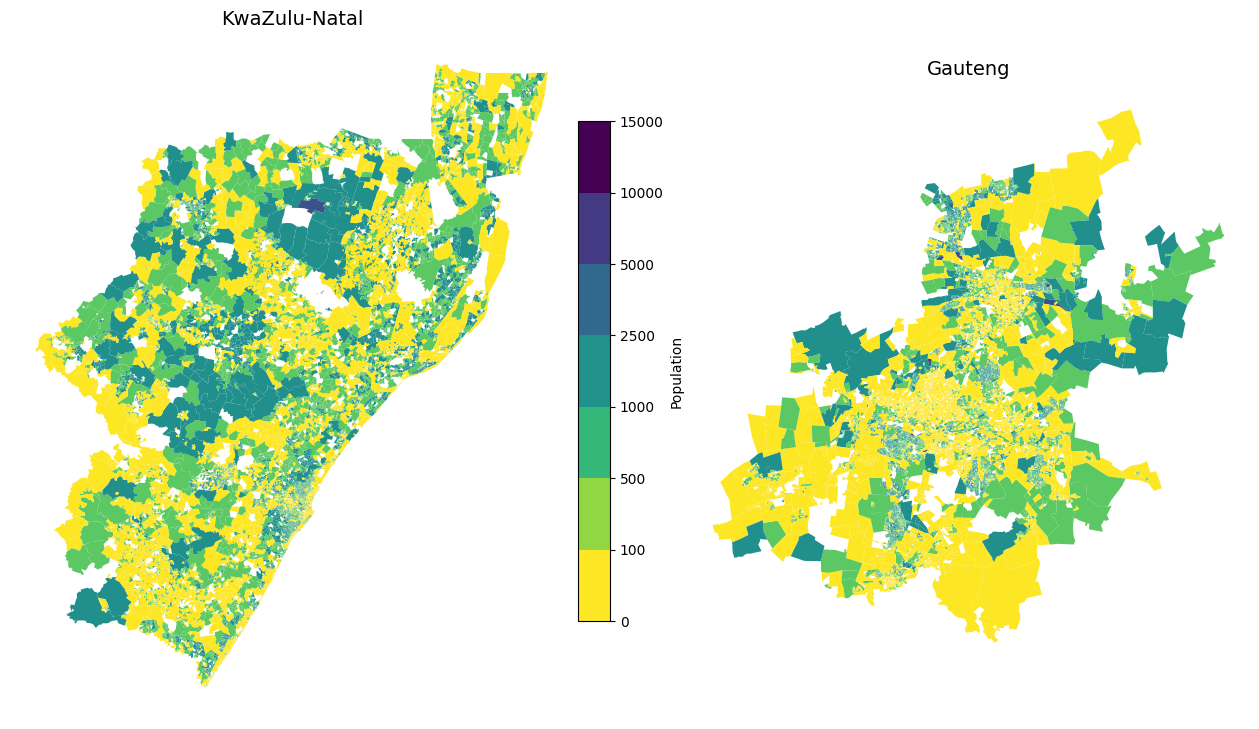

Map saved to pop2023estimate.png


In [1238]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

for i, prov in enumerate(provinces):
    
    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    subset = subset[subset['sal2023_est'].notna()]  # drop missing
    
    # compute quintile breaks
    bin_edges = [0, 100 , 500, 1000, 2500, 5000, 10000,15000 ]

    subset.plot(
        column='sal2023_est',
        cmap='viridis_r',
        legend=False,  # 🔥 turn off individual legends
        scheme='UserDefined',
        classification_kwds={'bins': bins},
        ax=axes[i]
    )
    
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# 🔥 Create shared colorbar in the middle
norm = mpl.colors.BoundaryNorm(bin_edges, ncolors=256)
sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

# [left, bottom, width, height] → tweak these numbers if needed
cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])  

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population")

output_file = "pop2023estimate.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

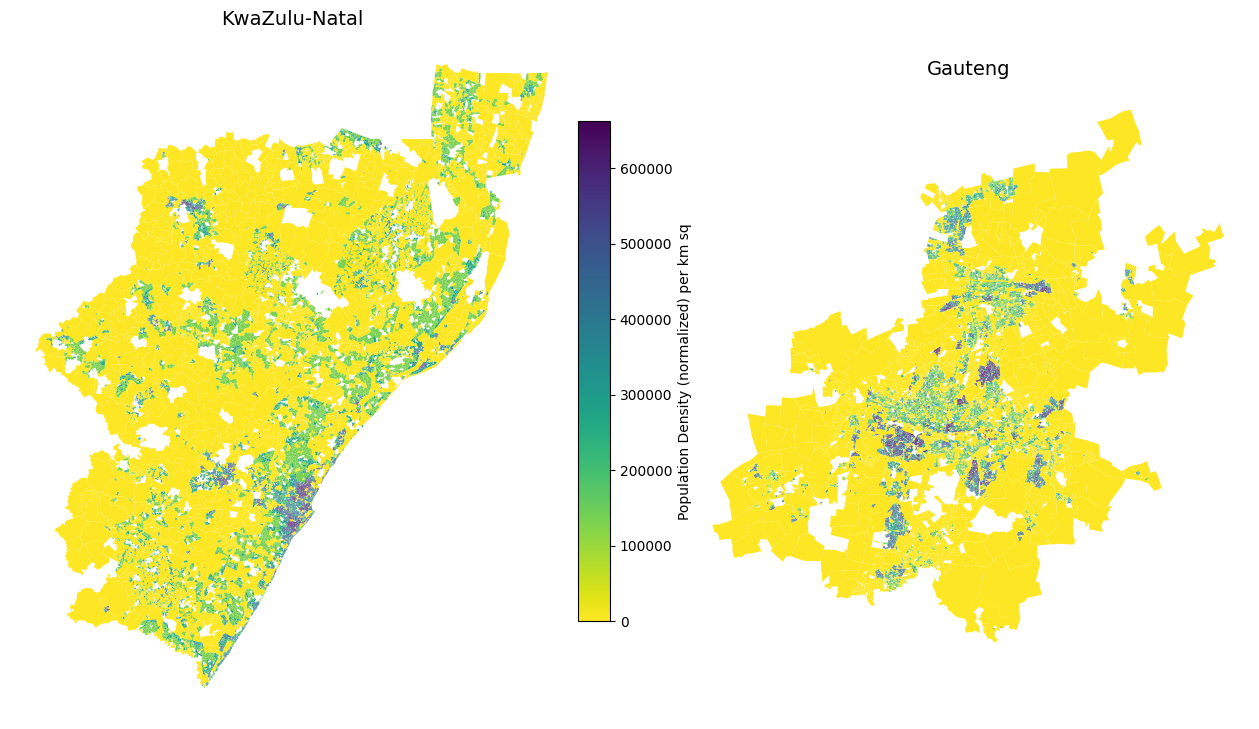

Map saved to popdensity.png


In [1239]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

for i, prov in enumerate(provinces):
    
    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    
    # compute quintile breaks
    subset.plot(
        column='sal_dense',
        cmap='viridis_r',
        legend=False,
        scheme='Quantiles',
        k=6,
        ax=axes[i]
    )
        
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# 🔥 Create shared colorbar in the middle
norm = mpl.colors.Normalize(
    vmin=sal_map['sal_dense'].min(),
    vmax=sal_map['sal_dense'].max()
)
sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

# [left, bottom, width, height] → tweak these numbers if needed
cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])  

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population Density (normalized) per km sq")

output_file = "popdensity.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

In [1240]:
sal_wards.to_csv('pop_pred_final.csv', index=False)

In [1241]:
sal_map = sal_map.to_crs(sal_with_ward.crs)

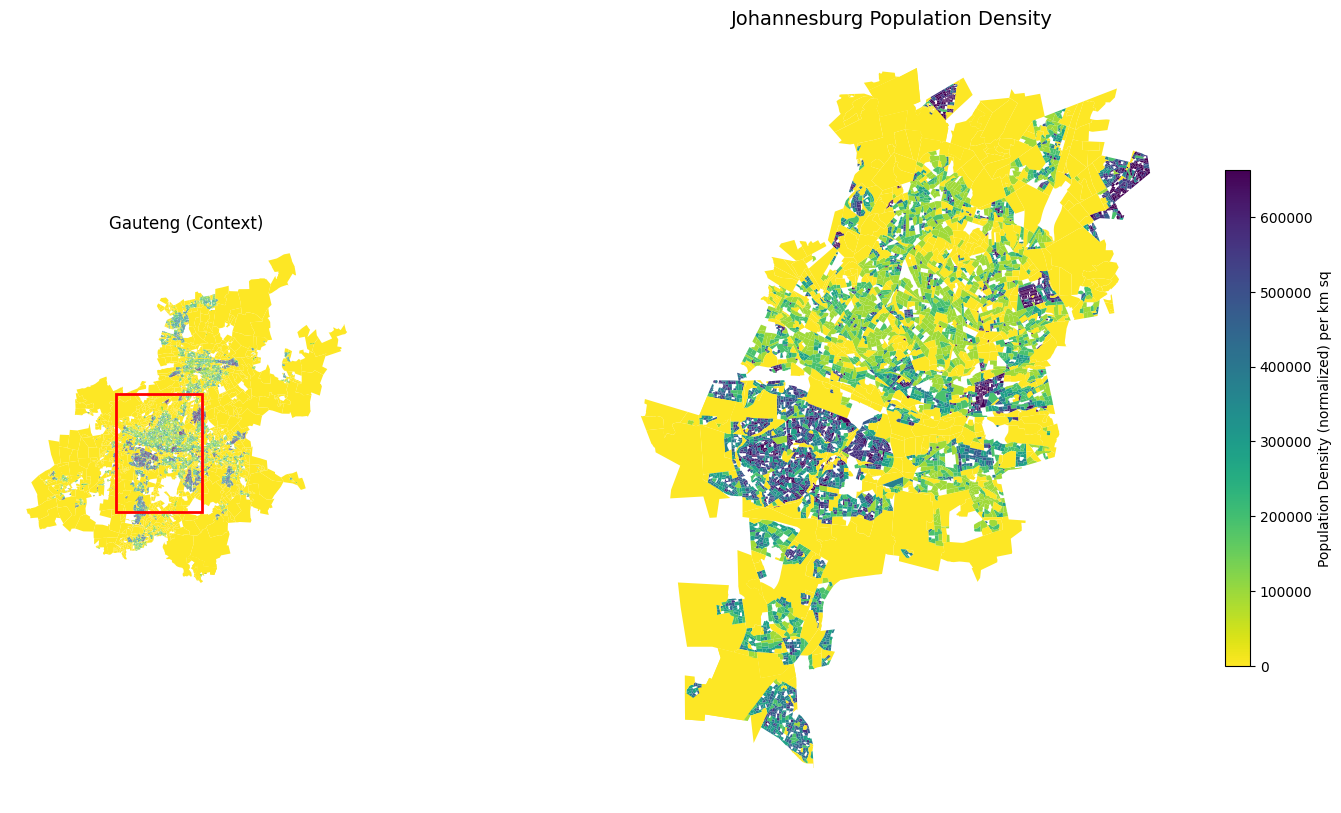

Map saved to gauteng_joburg_sidebyside_rect.png


In [1242]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

# -------------------------
# FILTER DATA
# -------------------------
gauteng = sal_map[sal_map['PR_NAME'].str.contains("Gauteng", case=False, na=False)].copy()

jhb = gauteng[gauteng['MN_NAME'].str.contains("Johannesburg", case=False, na=False)]

# -------------------------
# FIGURE (Joburg bigger)
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(16,10),
    gridspec_kw={'width_ratios': [1, 2]}  # Joburg panel bigger
)

# -------------------------
# LEFT: GAUTENG (context)
# -------------------------
gauteng.plot(
    column='sal_dense',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[0]
)

# Add rectangular outline for Johannesburg
xmin, ymin, xmax, ymax = jhb.total_bounds
pad_x = (xmax - xmin) * 0.02  # slight padding
pad_y = (ymax - ymin) * 0.02

rect = Rectangle(
    (xmin - pad_x, ymin - pad_y),
    (xmax - xmin) + 2*pad_x,
    (ymax - ymin) + 2*pad_y,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
axes[0].add_patch(rect)

axes[0].set_title("Gauteng (Context)", fontsize=12)
axes[0].axis('off')

# -------------------------
# RIGHT: JOHANNESBURG (zoom)
# -------------------------
jhb.plot(
    column='sal_dense',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[1]
)

axes[1].set_title("Johannesburg Population Density ", fontsize=14)
axes[1].axis('off')

# -------------------------
# SHARED COLORBAR
# -------------------------
norm = mpl.colors.Normalize(
    vmin=sal_map['sal_dense'].min(),
    vmax=sal_map['sal_dense'].max()
)

sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.02,
    pad=0.04
)
cbar.set_label("Population Density (normalized) per km sq")

# -------------------------
# SAVE
# -------------------------
output_file = "gauteng_joburg_sidebyside_rect.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()
print(f"Map saved to {output_file}")

In [ ]:
sal_wards['dens_norm'].describe()

In [141]:
print(sal_wards['share2011'].describe().to_markdown(index=False, floatfmt=",.2f"))

|   share2011 |
|------------:|
|   38,380.00 |
|        0.04 |
|        0.04 |
|        0.00 |
|        0.02 |
|        0.02 |
|        0.05 |
|        0.60 |


In [1233]:
sal_wards.loc[sal_wards['sal_dense'].idxmax()]

WardID               59500022
EA_CODE        59,913,668.000
sal2011_pop         1,306.000
ward2023_pop       21,793.914
EA_GTYPE                Urban
EA_TYPE              Township
econ_status       Non_Wealthy
houses2011             10.000
AREA                1,971.039
Black_Afri               1304
White                       0
Coloured                    2
Indian_or                   0
Other                       0
new_areakm              0.002
sal_dense         662,594.713
ward2011_sum       32,132.000
share2011               0.041
gweight                 1.320
dasym_weight            0.042
sal2023_est           919.229
growth_rate            -0.029
Name: 14059, dtype: object

In [ ]:
sal_wards.loc[sal_wards['sal2023_est'].idxmax()]